# 🎓 **CS331 <span style="color:#008080;"> PA 2 Part 1 — Predicting Car Fuel Efficiency with Linear Regression</span>**  

In this assignment, you’ll put your Machine Learning to test and build a <span style="color:#008080;">Linear Regression model</span> to find out what is making your car use so much fuel! Your task is to use **relevant selected car features** such as <span style="color:#f4a261;">engine horsepower</span> or the <span style="color:#6baed6;">car’s weight</span> to predict **MPG (miles per gallon)** — turning engine specs and car stats into _knobs_ (class reference, iykyk).

### General instructions
* Follow along with the notebook, filling out the necessary code where instructed.
*   Use separate training and testing data.
* <span style="color: red;">Make sure to run all cells for credit.</span>
* <span style="color: red;">Do not remove any pre-written code.</span> 
* <span style="color: red;">You must attempt all parts.</span> Do not assume that because something is for 0 marks, you can leave it - it will definitely be used in later parts.
* <span style="color: red;">Do not use unauthorized libraries.</span> You are not allowed to use `sklearn` for anything except train-test split.

**Allowed Libraries:**
*   Section 1 (from scratch): only `numpy`, `scipy`, `pandas`, `matplotlib`. You may only use `sklearn.model_selection.train_test_split` in this section; no other scikit-learn.
*   Section 2: you must use scikit-learn (details later).

## Auto MPG Dataset
This dataset provides characteristics of various cars from different model years and manufacturers, focusing on performance, design, and efficiency. The dataset contains 398 entries, each representing a car model, with features that correlate with a continuous Miles Per Gallon (MPG) score, which is the primary target variable.
The dataset was collected during the late 1970s and early 1980s, a time when fuel efficiency became a critical concern due to global oil crises.

**Features**



*  <span style="color:#6baed6;">MPG (miles per gallon):</span> A continuous variable representing the fuel efficiency of the car. This is the main target feature, with higher values indicating better efficiency.
* <span style="color:#6baed6;">Cylinders:</span> The number of cylinders in the engine. Cars with more cylinders tend to have higher power but lower fuel efficiency.  
*  <span style="color:#6baed6;">Displacement (cu in):</span> Engine displacement measured in cubic inches. Larger displacement generally indicates a more powerful engine but reduced MPG.
*  <span style="color:#6baed6;">Horsepower:</span> Engine power measured in horsepower. Higher horsepower can increase performance but often reduces fuel efficiency.
*  <span style="color:#6baed6;">Weight (lbs):</span> The weight of the car in pounds. Heavier cars usually consume more fuel, leading to lower MPG.
*  <span style="color:#6baed6;">Acceleration (0–60 mph in seconds):</span> The time taken for the car to accelerate from 0 to 60 miles per hour. Cars with lower acceleration times are faster but may sacrifice efficiency.


Start by importing the required libraries:

In [37]:
# Allowed everywhere
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# For 3D plots
from mpl_toolkits.mplot3d import Axes3D

DATA_PATH = "auto-mpg.csv"  # change if needed

# **Section 1**: Implementation from Scratch (70 Marks)
## 1. (EDA: Exploratory Data Analysis) (10 Marks)

### A. Data Loading & Cleaning
- Load the dataset into a pandas DataFrame.
- Convert the `"horsepower"` column to numeric (`pd.to_numeric(..., errors='coerce')`) so that `"?"` entries become `NaN`.
- Handle missing values (either drop rows with `NaN` or impute using mean/median).
- Keep only the relevant numeric columns for analysis.

### B. Scatter Plots
Create scatter plots of `mpg` vs:
- `weight`
- `horsepower`
- `displacement`
- `acceleration`
- `cylinders`
- `model year`

Each plot helps visualize how fuel efficiency (mpg) changes with respect to other variables.


### C. Feature Selection (3 features for modeling)


Initial Data Sample     mpg  cylinders  displacement horsepower  weight
0  18.0          8         307.0        130    3504
1  15.0          8         350.0        165    3693
2  18.0          8         318.0        150    3436
3  16.0          8         304.0        150    3433
4  17.0          8         302.0        140    3449
Cleaned Data Sample:
     mpg  cylinders  displacement  horsepower  weight
0  18.0          8         307.0       130.0    3504
1  15.0          8         350.0       165.0    3693
2  18.0          8         318.0       150.0    3436
3  16.0          8         304.0       150.0    3433
4  17.0          8         302.0       140.0    3449 



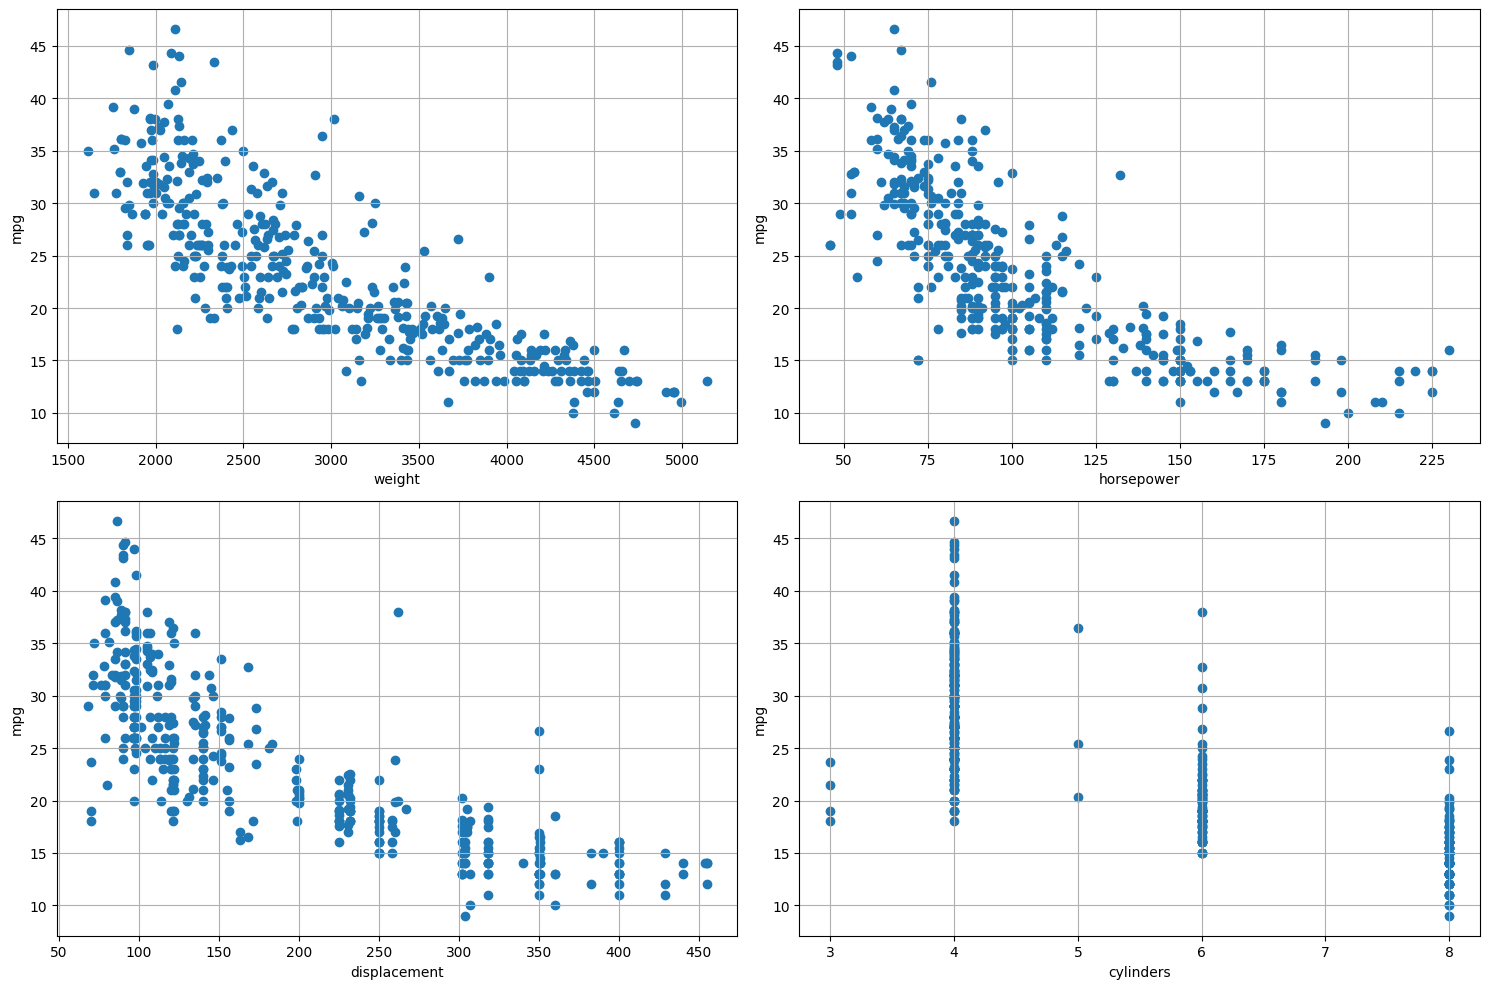

Chosen features: ['weight', 'horsepower', 'displacement']


In [38]:
# TODO: Load & clean
df = pd.read_csv(DATA_PATH)

print("Initial Data Sample", df.head())

df['horsepower'] = pd.to_numeric(df['horsepower'], errors= 'coerce')
df.dropna(inplace=True)

numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight']
df = df[numeric_cols]

print("Cleaned Data Sample:\n", df.head(), "\n")

# TODO: Scatter plots of mpg vs candidate features

fig, axes = plt.subplots(2,2, figsize=(15,10))
features_to_plot = ['weight', 'horsepower', 'displacement', 'cylinders', ]
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    axes[i].scatter(df[col], df['mpg'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('mpg')
    axes[i].grid(True)
    
plt.tight_layout()
plt.show()    

# TODO: Choose your three features based on EDA
features = ['weight', 'horsepower', 'displacement']  # edit after EDA
print("Chosen features:", features)

## 2. Normalizing Data (10 Marks)

### Why Standardization?
Standardization (z-score normalization) transforms each feature so that:
- Mean = 0  
- Standard Deviation = 1  

This ensures:
- Gradient descent is more stable and converges faster.  
- Features measured on different scales (e.g., horsepower vs. weight) become comparable.  
- Regularization (L1/L2 penalties) treats features fairly instead of being dominated by large-scale features.  

### Implementation

We implement a custom **StandardScaler** class with two methods:

#### A. `fit(X)`
- Compute the mean and standard deviation **only on the training set**.  
- Store these values for later use.  

#### B. `transform(X)`
- Use the stored training statistics to normalize each feature.  
- This means: for every feature, subtract its training mean and divide by its training standard deviation.  
- In this way, all features are rescaled to have mean 0 and standard deviation.

In [39]:
import numpy as np

class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        X= np.array(X, dtype= 'float')
        self.mean = np.mean(X, axis= 0)
        self.std = np.std(X, axis = 0)

    def transform(self, X):
        X = np.array(X, dtype= float)
        if self.mean is None or self.std is None:
            return X
        X_scaled = (X - self.mean) / self.std
        return X_scaled

## 3. Train/Test Split and Standardize (5 Marks)

### Train/Test Split (60/40)
We split the dataset into two parts:
- **60% training data** → used to fit the model and scaler.  
- **40% test data** → held out for final evaluation.  

This is done with a single call to `train_test_split`.

To ensure all features are on the same scale:
- We **fit the scaler only on the training set** (compute mean and std).  
- Then we apply the same transformation to the test set.  



In [40]:
# assumes: df (your data DataFrame), features (list of exactly 3 chosen feature names)
X_raw = df[features].to_numpy(dtype=float)
y     = df['mpg'].to_numpy(dtype=float).reshape(-1, 1)

X_train, X_test, yyyy_train, y_test = train_test_split( X_raw, y, test_size= 0.4 , random_state= 42)

ssccaler = StandardScaler()
ssccaler.fit(X_train)
print(yyyy_train.shape)
print(y_test.shape)
X_train_std = ssccaler.transform(X_train)
X_test = ssccaler.transform(X_test)


(235, 1)
(157, 1)


### 3D Scatter Plot (Training Set)
Finally, we plot the **standardized training features** in a 3D scatter plot:  
- The three axes correspond to the three selected features.  
- Each point represents a car in the dataset.  
- Points are **colored by mpg**, so we can visually inspect how fuel efficiency changes across feature space.  

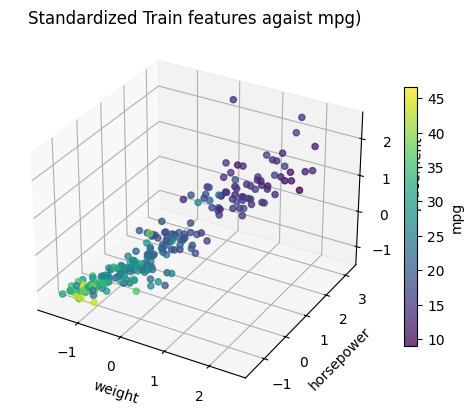

In [41]:
# --- 3D scatter of TRAIN (standardized) ---
# Assumes variables (change names if you used different ones):
# X_train_std: standardized training data
# y_train: y labels of training data

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(
    X_train_std[:, 0], X_train_std[:, 1], X_train_std[:, 2],
    c=yyyy_train.ravel(), alpha=0.75
)

ax.set_xlabel(features[0])
ax.set_ylabel(features[1])
ax.set_zlabel(features[2])
ax.set_title("Standardized Train features agaist mpg)")

fig.colorbar(p, shrink=0.7, label="mpg")
plt.show()

## 4. Linear Regression Model (40 Marks)

**Notation (shapes)**
- Let $m$ = #examples, $d$ = #features (**here $d=3$**).
- $X \in \mathbb{R}^{m\times d}$: standardized features (from `StandardScaler`).
- $\tilde{X} = [\mathbf{1} \mid X] \in \mathbb{R}^{m\times(d+1)}$: features **with a bias column** of 1s.
- $\theta \in \mathbb{R}^{(d+1)\times 1}$: parameters (first entry is the bias).
- $y \in \mathbb{R}^{m\times 1}$: targets (mpg).



**Hypothesis (prediction)**

$$
\hat{y} = \tilde{X}\,\theta
$$

Equivalently (separating bias and weights):

$$
\hat{y} = X\,w + b \quad\text{with}\quad \theta = \begin{bmatrix} b \\[2pt] w \end{bmatrix}.
$$



**Loss (MSE with 1/2)**

$$
J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\big(\hat y^{(i)} - y^{(i)}\big)^2
= \frac{1}{2m}\,\lVert \tilde{X}\theta - y \rVert_2^2
$$



**Gradient**

Let $r=\tilde{X}\theta - y$. Then

$$
\nabla_{\theta} J(\theta) = \frac{1}{m}\,\tilde{X}^\top(\tilde{X}\theta - y).
$$



**Batch Gradient Descent (BGD) update**

$$
\theta \leftarrow \theta \;-\; \alpha \cdot \frac{1}{m}\,\tilde{X}^\top(\tilde{X}\theta - y).
$$



Now that your data is ready, you should implement the gradient descent algorithm inside a class `LinearRegression`. The class should include the following methods:

- `__init__`: The constructor of the class. Set up the learning rate, convergence tolerance, random seed, and prepare variables to store weights, bias, gradients, and cost history.

- `initialize_parameters`: Initialize the model parameters (weights and bias) before training begins.

- `forward`: Take the input features and compute the predictions of the model.

- `compute_cost`: Compute the cost function using Mean Squared Error with a 1/2 factor. This value should be saved after each iteration.

- `backward`: Calculate the gradients of the cost function with respect to the weights and bias using the training data.

- `fit`: Train the model by running gradient descent for a fixed number of iterations (or until convergence). In each iteration call `forward`, `compute_cost`, `backward`, and then update the parameters. Also, keep track of the cost values and optionally plot them at the end.

- `predict`: Use the learned parameters to predict the output for new input data.

- `score` : Evaluate model performance on test data by returning a metric such as MSE.

**Deliverables**  
- Plot the training cost curve (MSE/2) against the number of iterations. 
- Report model performance on both train and test data (MSE).  


In [42]:
class LinearRegression:
    def __init__(self, n_features, learning_rate=0.01, seed=42):
        
        np.random.seed(seed)
        self.weights = np.random.randn(n_features, 1) * learning_rate
        self.biassss = 0.0

        self.dweights = None  #! to hold gradients
        self.dbiasss = None
        
        self.X = None #! to hold data as told in FAQs
        self.y = None
        self.cost_history = None
        self.learningRAATE = learning_rate;
        
    def forward(self, X):
        return X @ self.weights + self.biassss

    def compute_cost(self, predictions):
        m = len(self.y)
        cost = (1/ (2*m)) * np.sum((predictions - self.y) ** 2)
        return cost
        
    def backward(self, predictions):
        m = len(self.y)
        self.dweights = (1 / m) * (self.X.T @ (predictions - self.y))
        self.dbiasss =  (1/ m) * np.sum(predictions - self.y)
        

    def fit(self, X, y, iterations, plot_cost=False):
        self.X = X
        self.y = y
        
        self.cost_history = []
        for i in range(iterations):
            predictions = self.forward(self.X)
            cost = self.compute_cost(predictions)
            
            self.cost_history.append(cost)
            self.backward(predictions)
            
            self.weights -= self.learningRAATE * self.dweights
            self.biassss -= self.learningRAATE * self.dbiasss         
            
        return self

    def predict(self, X):
        return self.forward(X)



## 5. Evaluation (5 Marks)

After training your `LinearRegression` model, you should evaluate its performance:

1. **Plot the cost function**  
   - This shows how the cost (MSE/2) decreases over iterations.

2. **Report Mean Squared Error (MSE)**  
   - Compute and print the MSE for both the **training set** and the **test set**.  
   - This allows you to compare how well the model fits the training data and how well it generalizes to unseen data.

**Your train loss should be around 17.0 and test loss should be around 20.0**


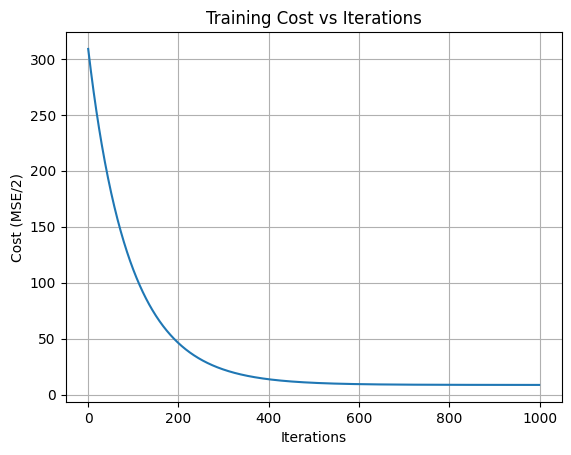

Train MSE:  17.199874736896735
Test MSE:  20.23628871484502


In [43]:
# Hyperparameters
n_epochs = 1000
alpha    = 0.005

# Train the model
lr = LinearRegression(n_features=3, learning_rate=alpha)

lr.fit(X_train_std, yyyy_train, iterations= n_epochs, plot_cost= False)
# Plot cost curve (MSE/2 from training)

plt.plot(lr.cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE/2)")
plt.title("Training Cost vs Iterations")
plt.grid(True)
plt.show()

# Evaluate on train data
yyy_train_pred = lr.predict(X_train_std)
train_mse = (1/ (2 * len(yyyy_train))) * np.sum((yyy_train_pred - yyyy_train) ** 2) * 2

# Evaluate on test data
y_test_predd = lr.predict(X_test)
test_mse = (1/(2 * len(y_test))) * np.sum((y_test_predd - y_test) ** 2) * 2

# Print results
print("Train MSE: ", train_mse)
print("Test MSE: ", test_mse)

### Print the Learnt Model Weights 
Print the bias and model weights, we will use these for comparison later.

In [44]:
print("Learned weights (W):", lr.weights)
print("Learned bias (b):", lr.biassss)

Learned weights (W): [[-2.98833222]
 [-2.20067757]
 [-1.99259137]]
Learned bias (b): 23.347436042347574


### Visualizing the Learnt Function - Another 3D Scatter plot
We will now plot the **learnt function** on the **standardized training features** in a 3D scatter plot. This is similar to the earlier feature plot we made, except we now superpose our learnt function on it. 
- The three axes correspond to the three selected features.  
- Each point represents a car in the dataset.  
- Points are **colored by mpg**, so we can visually inspect how fuel efficiency changes across feature space.  
- We see **diffused points** all across the 3D space now - their colors represent the mpg value your model **predicts** for that combination of the three features. So while we initially had a few real data points against their real mpg value, we now have a function that produces an mpg value against every possible data point (a data point being a specific combination of the features). This means that we have discovered or at least estimated the underlying unknown probability function itself that gives rise to the data - **that's the magical power of regression**!
- Your model is great if the predicted colors match the colors of the real data points in each region.

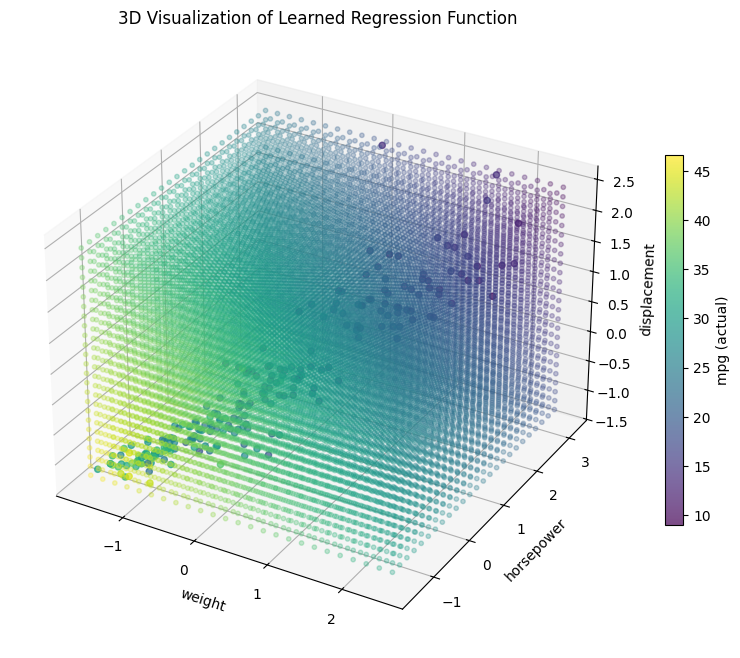

In [45]:
# Define feature ranges — smaller grid for fewer predicted points

# Variables (change names if you used different ones):
# X_train_std: standardized training data
# y_train: y labels of training data

x_range = np.linspace(X_train_std[:, 0].min(), X_train_std[:, 0].max(), 25)
y_range = np.linspace(X_train_std[:, 1].min(), X_train_std[:, 1].max(), 25)
z_range = np.linspace(X_train_std[:, 2].min(), X_train_std[:, 2].max(), 25)

# Create 3D grid for predictions
x_surf, y_surf, z_surf = np.meshgrid(x_range, y_range, z_range)
points = np.c_[x_surf.ravel(), y_surf.ravel(), z_surf.ravel()]
predicted = lr.predict(points).reshape(x_surf.shape)

# === Plot ===
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter all actual training data
p = ax.scatter(
    X_train_std[:, 0], X_train_std[:, 1], X_train_std[:, 2],
    c=yyyy_train.ravel(), cmap='viridis', alpha=0.7, label='Training data'
)

# Overlay sparse model predictions
ax.scatter(
    x_surf.ravel(), y_surf.ravel(), z_surf.ravel(),
    c=predicted.ravel(), cmap='viridis', alpha=0.3, s=10, label='Model predictions'
)

# Axis labels and title
ax.set_xlabel(features[0])
ax.set_ylabel(features[1])
ax.set_zlabel(features[2])
ax.set_title('3D Visualization of Learned Regression Function')

# Colorbar on same scale as mpg
fig.colorbar(p, ax=ax, label='mpg (actual)', shrink=0.6)

plt.show()


# **Section 2** (30 Marks)

## Linear Regression using Scikit-learn (15 Marks)
We first fit an **Ordinary Least Squares (OLS)** linear regression model using `sklearn.LinearRegression`.  
The model is trained on the standardized training data, and the Mean Squared Error (MSE/2) is reported for both training and test sets.



In [46]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Train Linear Regression model
lr_sklearn =LinearRegression()
lr_sklearn.fit(X_train_std, yyyy_train)

# Predictions
y_train_predd_sklearn = lr_sklearn.predict(X_train_std)
y_test_predd_sklearn = lr_sklearn.predict(X_test)

# Mean Squared Error
train_mse_sklearn = mean_squared_error(yyyy_train, y_train_predd_sklearn)
test_mse_sklearn = mean_squared_error(y_test, y_test_predd_sklearn)

print("Train MSE / 2", train_mse_sklearn / 2)
print("Test MSE / 2", test_mse_sklearn / 2)

Train MSE / 2 8.485685840823903
Test MSE / 2 10.008463255698253


## Ridge Regression (5 Marks)

Next, we apply **Ridge Regression** (L2 regularization).  
Use the `mean_squared_error` to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Ridge.

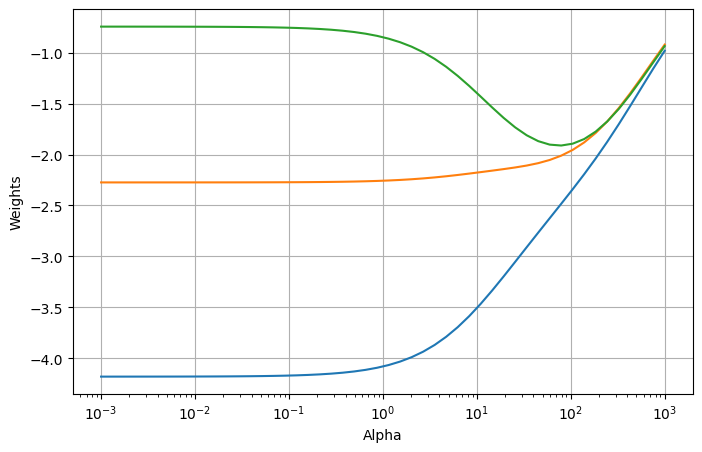

In [47]:
alphas = np.logspace(-3, 3, 50)
Ridge_weights = []

for alph in alphas:
    ridge = Ridge(alpha= alph)
    ridge.fit(X_train_std, yyyy_train)

    yyy_train_pred = ridge.predict(X_train_std)
    y_test_predd = ridge.predict(X_test)
    
    train_mse = mean_squared_error(yyyy_train, yyy_train_pred)
    test_mse = mean_squared_error(y_test, y_test_predd)
    Ridge_weights.append(ridge.coef_.flatten())
    
Ridge_weights = np.array(Ridge_weights)

plt.figure(figsize=(8,5))
for i in range(Ridge_weights.shape[1]):
    plt.plot(alphas, Ridge_weights[:, i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Weights")
plt.grid(True)
plt.show()


## Lasso Regression (5 Marks)

Finally, we apply **Lasso Regression** (L1 regularization).  

Use the `mean_squared_error` to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Lasso.

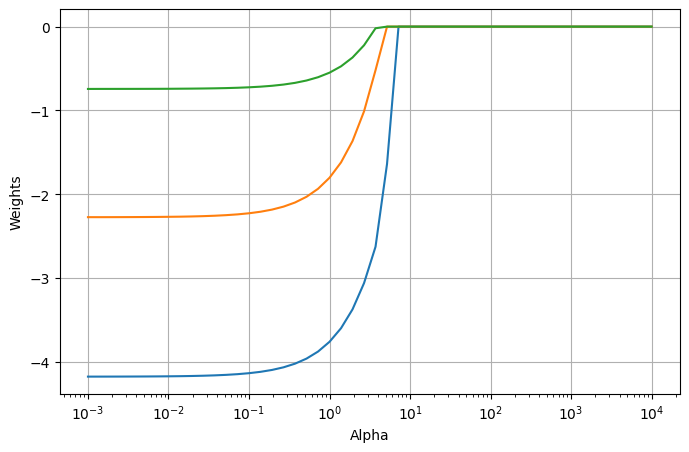

In [48]:
alphas = np.logspace(-3, 4, 50)
Lasso_weights = []

for alph in alphas:
    lasso = Lasso(alpha= alph)
    lasso.fit(X_train_std, yyyy_train)

    yyy_train_pred = lasso.predict(X_train_std)
    y_test_predd = lasso.predict(X_test)
    
    train_mse = mean_squared_error(yyyy_train, yyy_train_pred)
    test_mse = mean_squared_error(y_test, y_test_predd)
    Lasso_weights.append(lasso.coef_.flatten())
    
Lasso_weights = np.array(Lasso_weights)

plt.figure(figsize=(8,5))
for i in range(Lasso_weights.shape[1]):
    plt.plot(alphas, Lasso_weights[:, i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Weights")
plt.grid(True)
plt.show()


## Comparison on Coefficients - Regularized vs. Non-Regularized (5 Marks)
a) Explain what the Ridge and Lasso parameter graphs show. 

b) Briefly discuss the difference between the model coefficients (weights) of your initial model and the regularized models. How and why are they different?

#### Answer Here:
The Ridge and lasso graphs plot how the weights change as the alphas increases
When alpha is very small, the penalty term is weak, the model behaves like ordinary linear regression
When alphas increases, the penalty term grows, weights are shrunk towards zero to prevent overfitting

Ridge Regression:
- Weights decrease smoothly and gradually towards 0 as alphas increase
None of the cooefficents become exactly 0

Lasso Regression:
- Weights also decrease as alphas increase but in a sparse manner
 Some weights become exactly 0, removing less important features completely 
 